## **Import Libraries**

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

from scipy import stats

# Reproducibility
RANDOM_STATE = 42

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


## **Data Load**

In [3]:
DATA_PATH = "student-mat.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (395, 33)


### *Dataset Overview*

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 10 observations:")
display(df.head(10))

Number of rows: 395
Number of columns: 33

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 10 observations:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


### *Dataset Information*

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

### *DATA TYPES*

In [6]:
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing Values": [df[col].isna().sum() for col in df.columns]
})

display(dtype_summary)

,Column,Data Type,Unique Values,Missing Values
0,school,object,2,0
1,sex,object,2,0
2,age,int64,8,0
3,address,object,2,0
4,famsize,object,2,0
5,Pstatus,object,2,0
6,Medu,int64,5,0
7,Fedu,int64,5,0
8,Mjob,object,5,0
9,Fjob,object,5,0


## **Missing Value Analysis**

In [7]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
school,0,0.0
sex,0,0.0
age,0,0.0
address,0,0.0
famsize,0,0.0
Pstatus,0,0.0
Medu,0,0.0
Fedu,0,0.0
Mjob,0,0.0
Fjob,0,0.0


## **Duplicate Record Analysis**

In [8]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(
        by=df.columns.tolist()
    ).head(20))

Number of duplicate rows: 0


## **DESCRIPTIVE STATISTICS**

In [9]:
print("Numerical descriptive statistics:")

display(
    df.describe().T.round(3)
)

Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696,1.276,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749,1.095,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.522,1.088,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448,0.698,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035,0.839,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334,0.744,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944,0.897,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235,0.999,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.109,1.113,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481,0.891,1.0,1.0,1.0,2.0,5.0


## **VARIABLE TYPES**

In [10]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical variables:")
print(categorical_columns)

print("\nNumerical variables:")
print(numerical_columns)

Categorical variables:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical variables:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


### *CATEGORICAL VARIABLE DISTRIBUTIONS*

In [11]:
for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"{column}")
    print(f"{'=' * 60}")
    print(df[column].value_counts())


school
school
GP    349
MS     46
Name: count, dtype: int64

sex
sex
F    208
M    187
Name: count, dtype: int64

address
address
U    307
R     88
Name: count, dtype: int64

famsize
famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus
Pstatus
T    354
A     41
Name: count, dtype: int64

Mjob
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

Fjob
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

reason
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

guardian
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

schoolsup
schoolsup
no     344
yes     51
Name: count, dtype: int64

famsup
famsup
yes    242
no     153
Name: count, dtype: int64

paid
paid
no     214
yes    181
Name: count, dtype: int64

activities
activities
yes    201
no     194
Name: count, dtype: int64

nu

## **TARGET VARIABLE ANALYSIS**

In [12]:
TARGET = "G3"

print("Target variable:", TARGET)
print("Target data type:", df[TARGET].dtype)

print("\nTarget descriptive statistics:")
display(df[TARGET].describe().round(3))

print("\nTarget frequency distribution:")
display(
    df[TARGET]
    .value_counts()
    .sort_index()
    .to_frame("Frequency")
)

Target variable: G3
Target data type: int64

Target descriptive statistics:


,G3
count,395.000
mean,10.415
std,4.581
min,0.000
25%,8.000
50%,11.000
75%,14.000
max,20.000



Target frequency distribution:


,Frequency
G3,
0,38
4,1
5,7
6,15
7,9
8,32
9,28
10,56
11,47


### *G3 DISTRIBUTION*

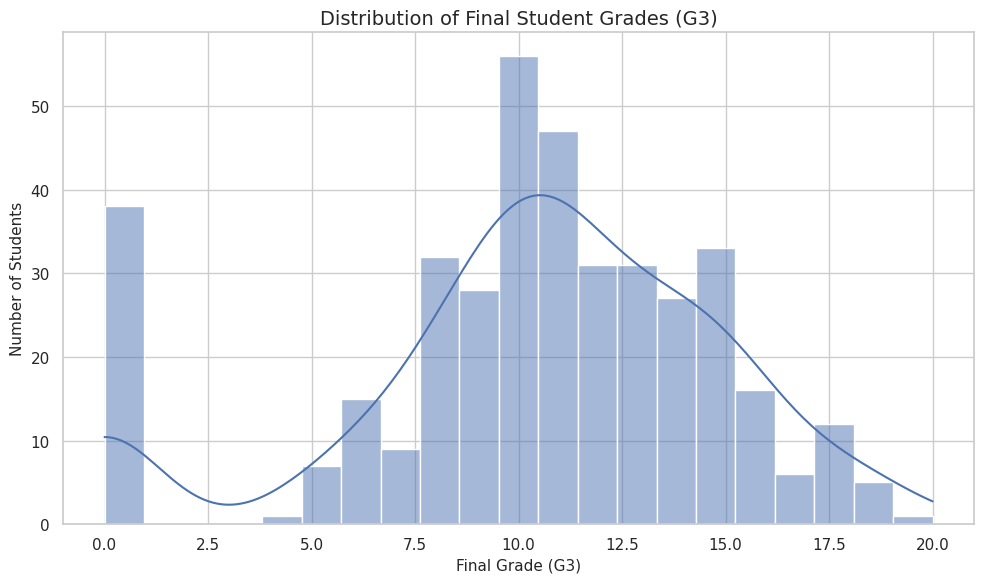

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df[TARGET],
    bins=21,
    kde=True
)

plt.title("Distribution of Final Student Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### *G3 BOXPLOT*

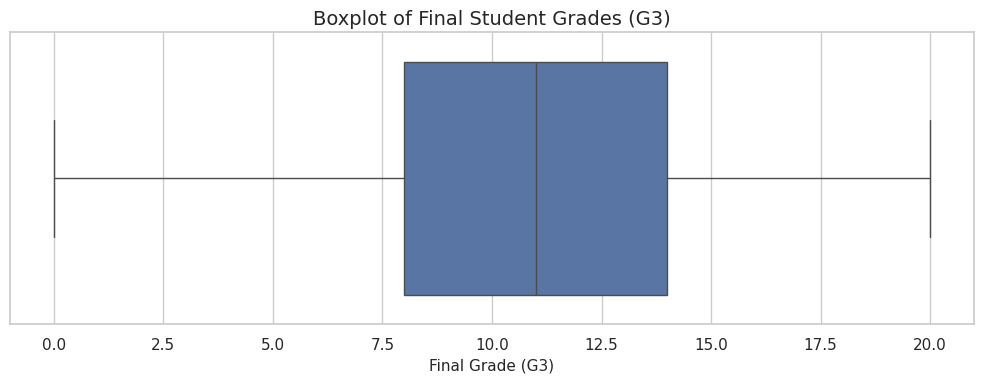

In [14]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df[TARGET]
)

plt.title("Boxplot of Final Student Grades (G3)")
plt.xlabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *TARGET DISTRIBUTION STATISTICS*

In [15]:
g3_skewness = df[TARGET].skew()
g3_kurtosis = df[TARGET].kurtosis()

print(f"G3 skewness: {g3_skewness:.4f}")
print(f"G3 kurtosis: {g3_kurtosis:.4f}")

G3 skewness: -0.7327
G3 kurtosis: 0.4034


## **Numerical Correlation Analysis**

In [16]:
correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

display(
    correlation_matrix[TARGET]
    .sort_values(ascending=False)
    .to_frame("Correlation with G3")
)

,Correlation with G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
Walc,-0.051939


### *Correlation Heatmap*

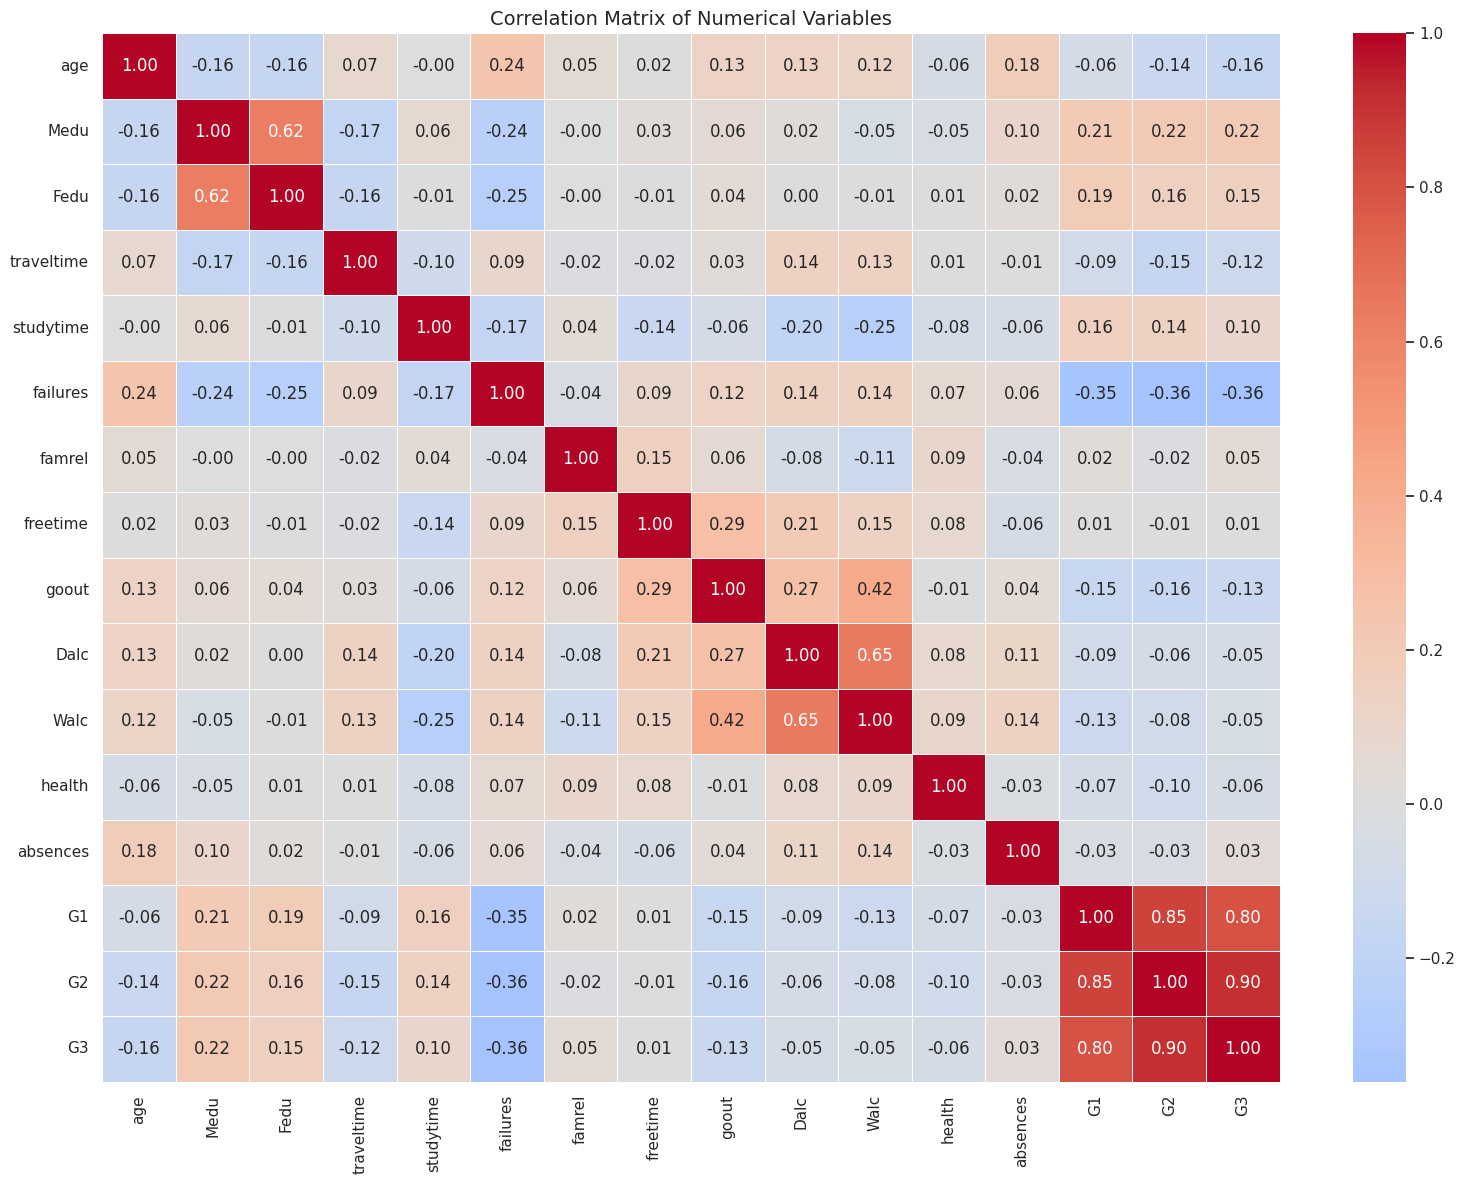

In [17]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

## **G1/G2 RELATIONSHIP WITH G3**

In [18]:
g1_g2_corr = df[["G1", "G2", "G3"]].corr()

display(g1_g2_corr)

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


### *G1 VS G3*

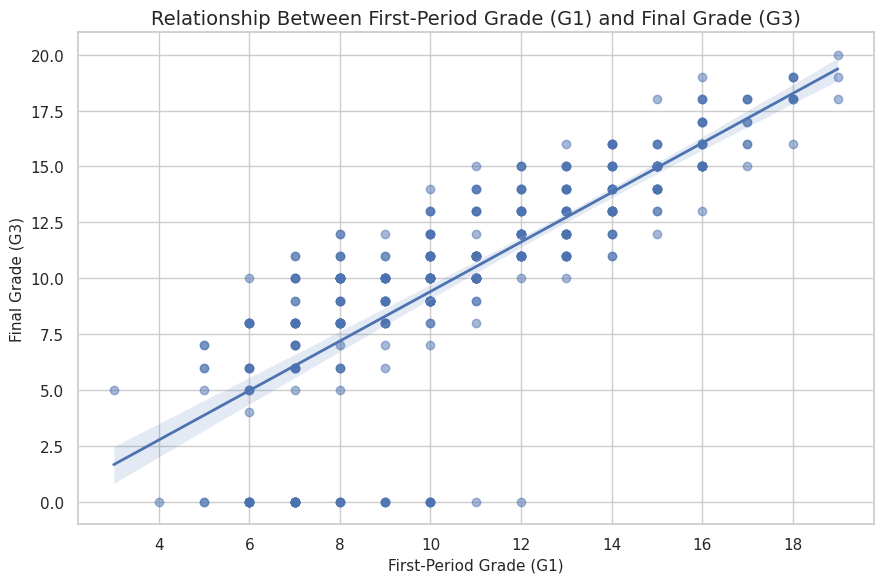

In [19]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="G1",
    y="G3",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between First-Period Grade (G1) and Final Grade (G3)")
plt.xlabel("First-Period Grade (G1)")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *G2 VS G3*

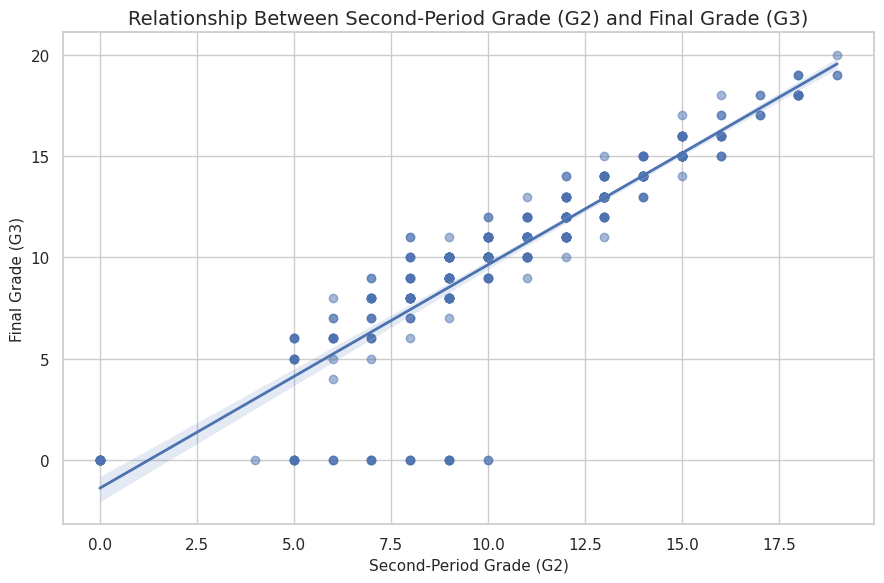

In [20]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="G2",
    y="G3",
    scatter_kws={"alpha": 0.5},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Second-Period Grade (G2) and Final Grade (G3)")
plt.xlabel("Second-Period Grade (G2)")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

## **EDA**

### *STUDY TIME VS G3*

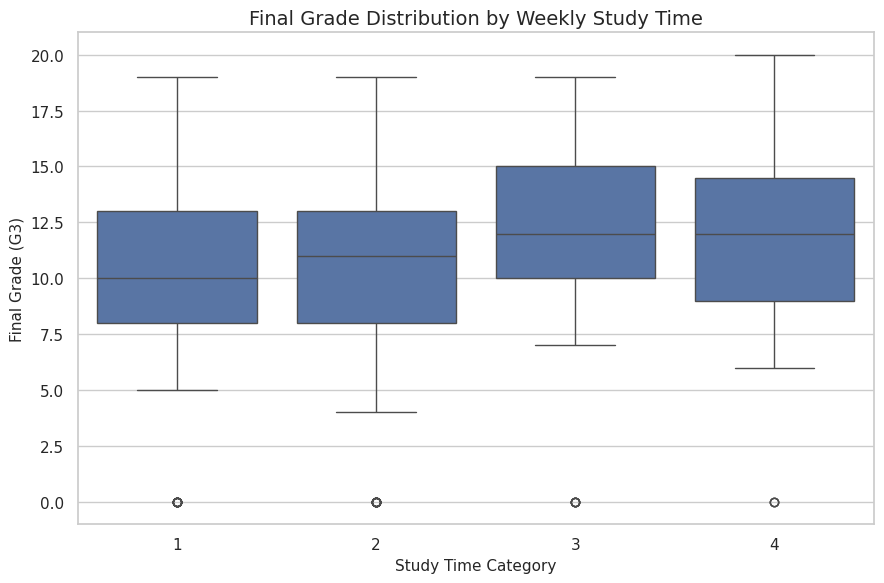

In [21]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3"
)

plt.title("Final Grade Distribution by Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *FAILURES VS G3*

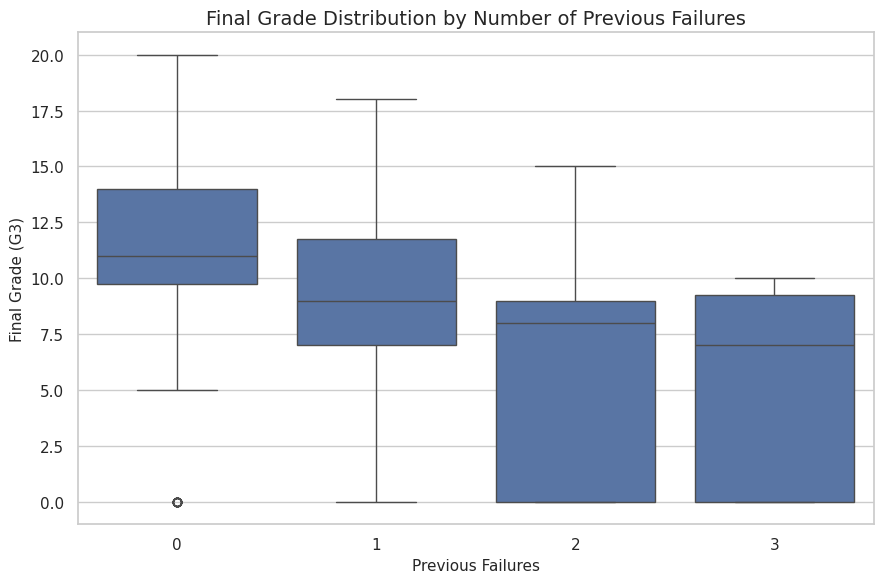

In [22]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="failures",
    y="G3"
)

plt.title("Final Grade Distribution by Number of Previous Failures")
plt.xlabel("Previous Failures")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *ABSENCES VS G3*

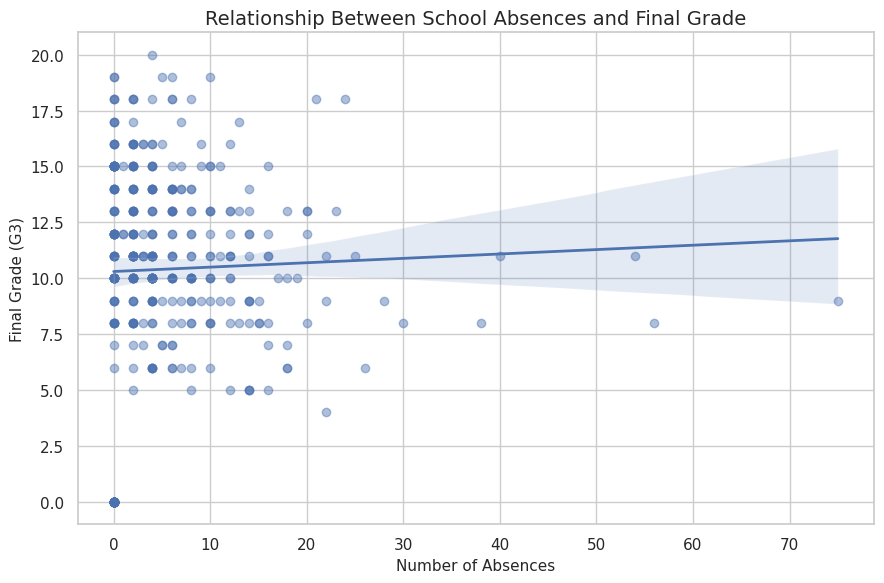

In [23]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="absences",
    y="G3",
    scatter_kws={"alpha": 0.45},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between School Absences and Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *PARENTAL EDUCATION VS G3*

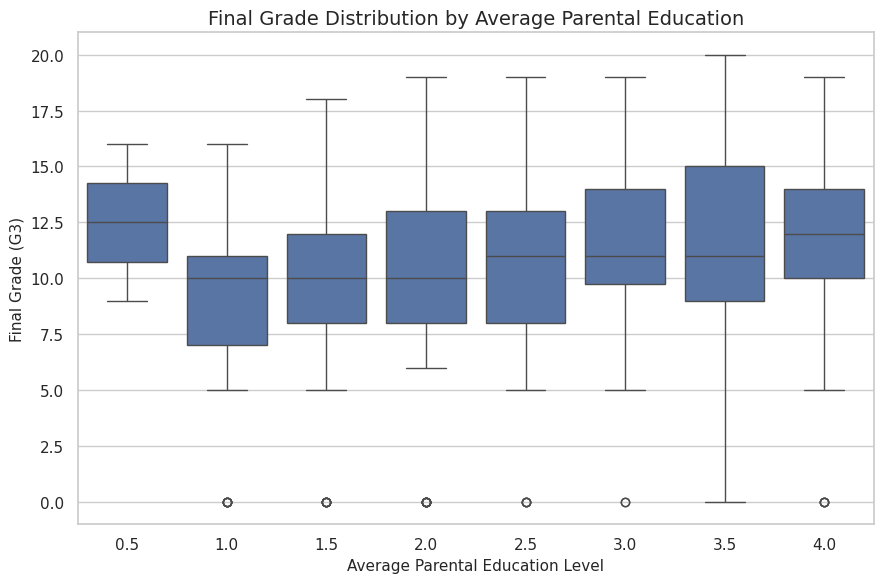

In [24]:
df["parent_education_average"] = (
    df["Medu"] + df["Fedu"]
) / 2

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="parent_education_average",
    y="G3"
)

plt.title("Final Grade Distribution by Average Parental Education")
plt.xlabel("Average Parental Education Level")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *GENDER VS G3*

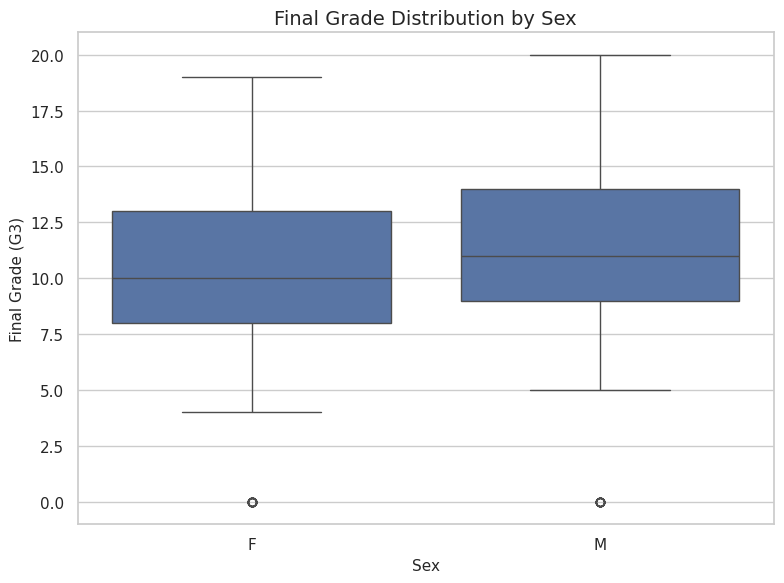

In [25]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="sex",
    y="G3"
)

plt.title("Final Grade Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *SCHOOL VS G3*

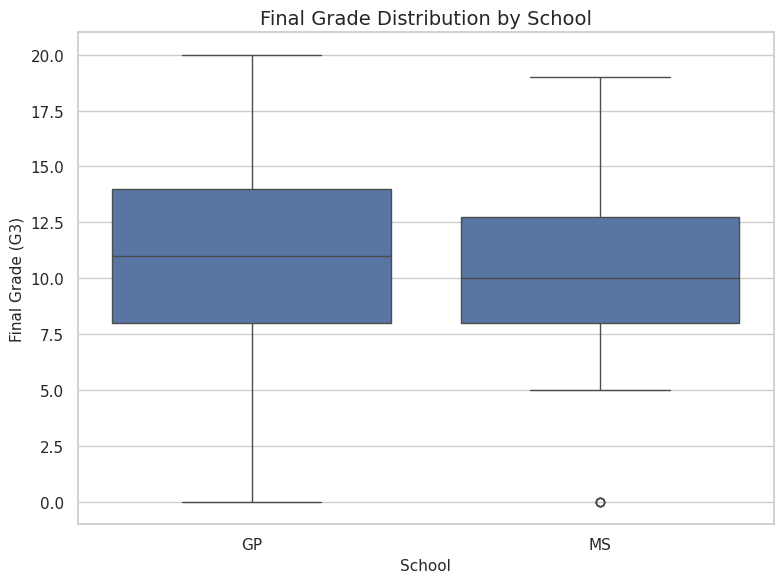

In [26]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="school",
    y="G3"
)

plt.title("Final Grade Distribution by School")
plt.xlabel("School")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *INTERNET ACCESS VS G3*

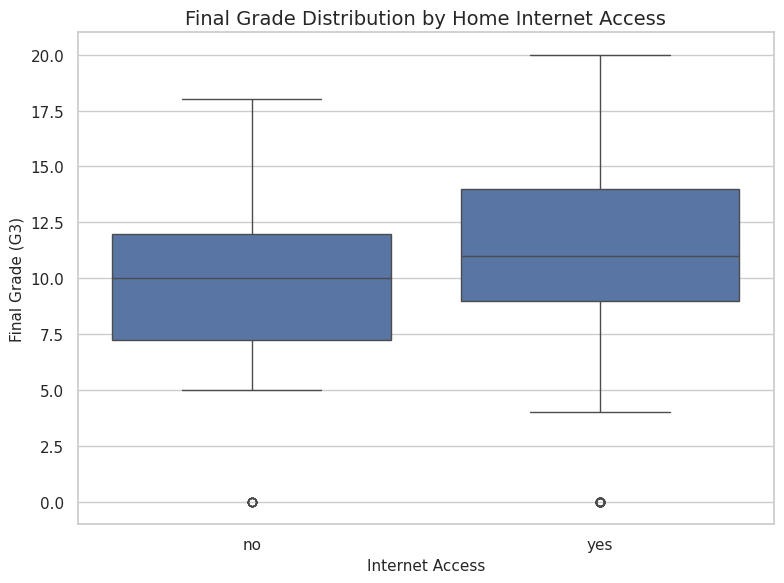

In [27]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="internet",
    y="G3"
)

plt.title("Final Grade Distribution by Home Internet Access")
plt.xlabel("Internet Access")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *HIGHER EDUCATION ASPIRATION VS G3*

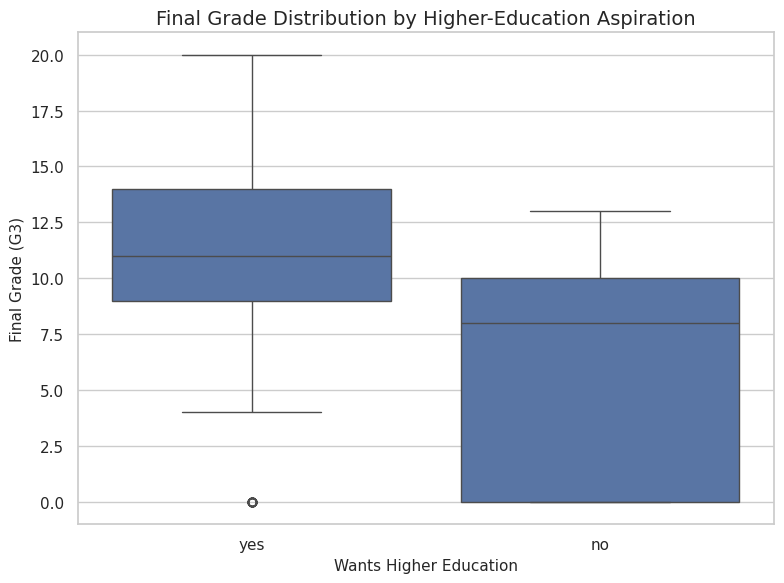

In [28]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="higher",
    y="G3"
)

plt.title("Final Grade Distribution by Higher-Education Aspiration")
plt.xlabel("Wants Higher Education")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

### *SCHOOL SUPPORT VS G3*

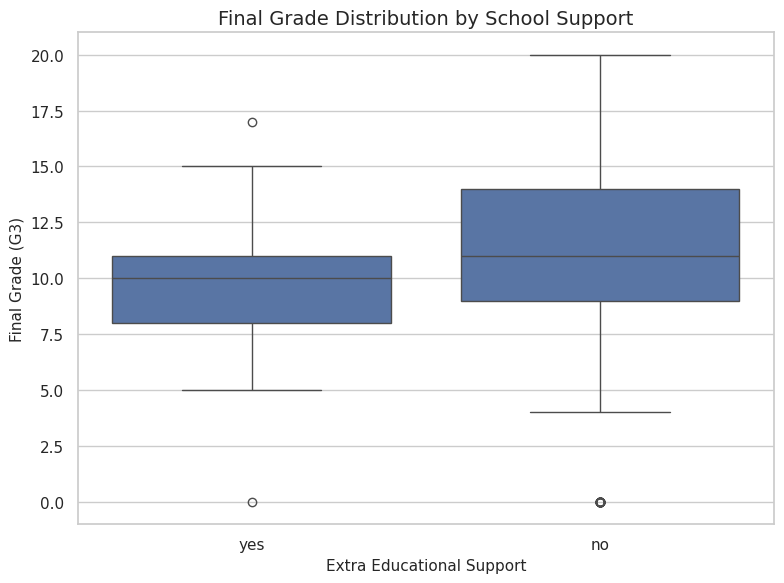

In [29]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="schoolsup",
    y="G3"
)

plt.title("Final Grade Distribution by School Support")
plt.xlabel("Extra Educational Support")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

## **AUTOMATED CATEGORICAL EDA**

## **AUTOMATED NUMERICAL EDA**

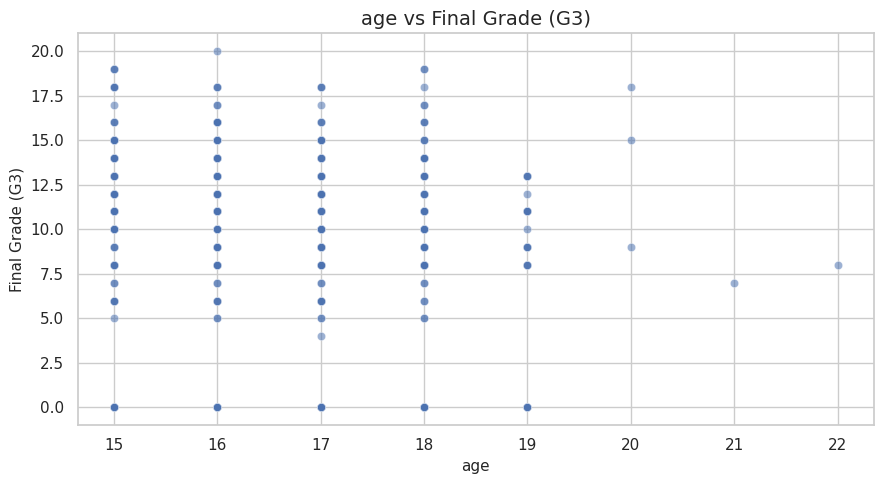

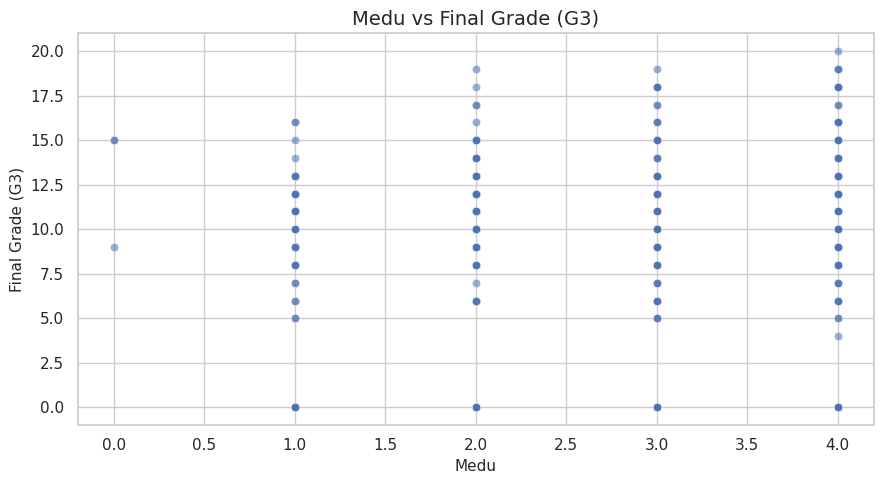

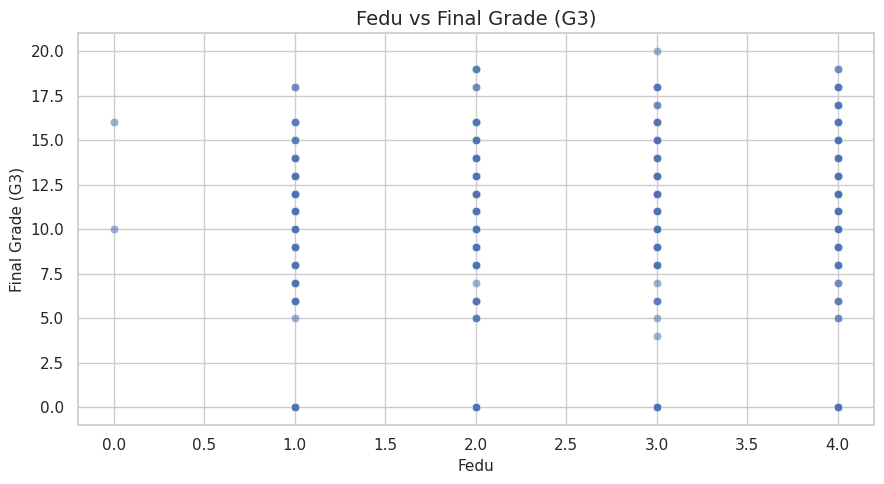

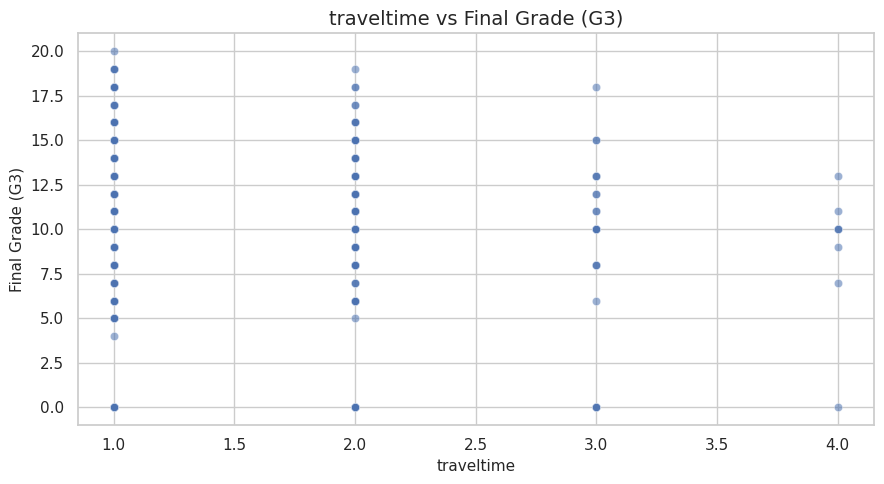

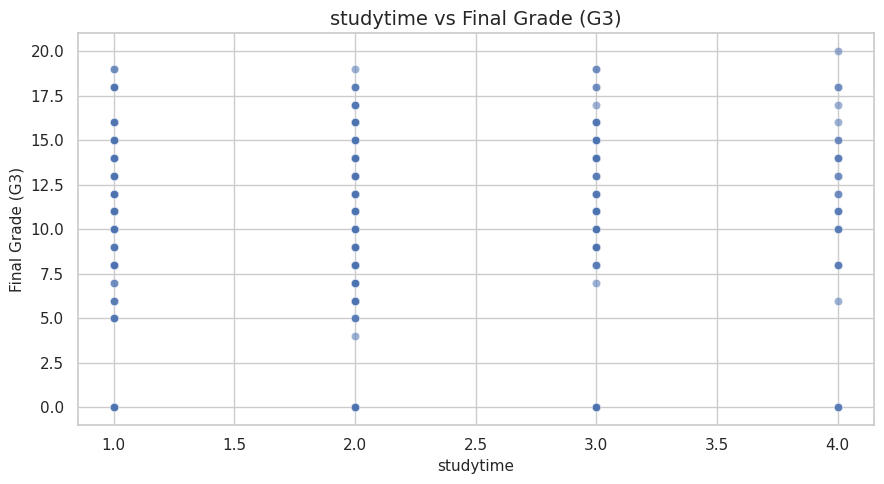

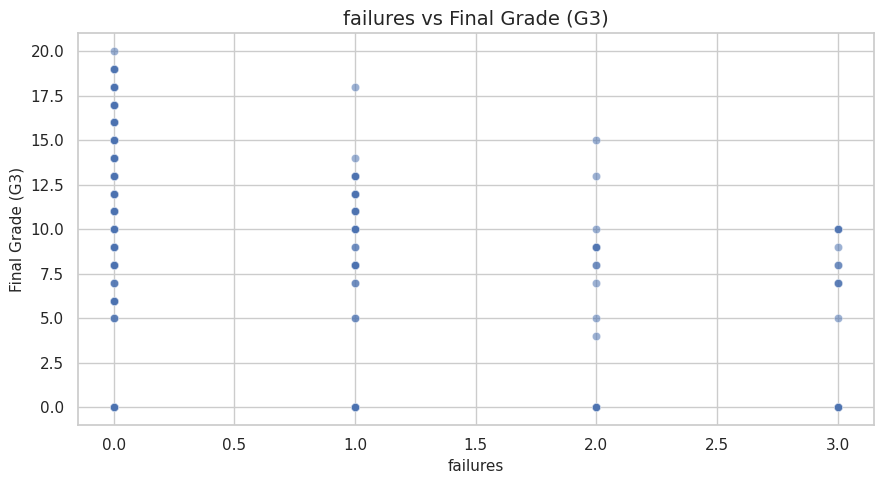

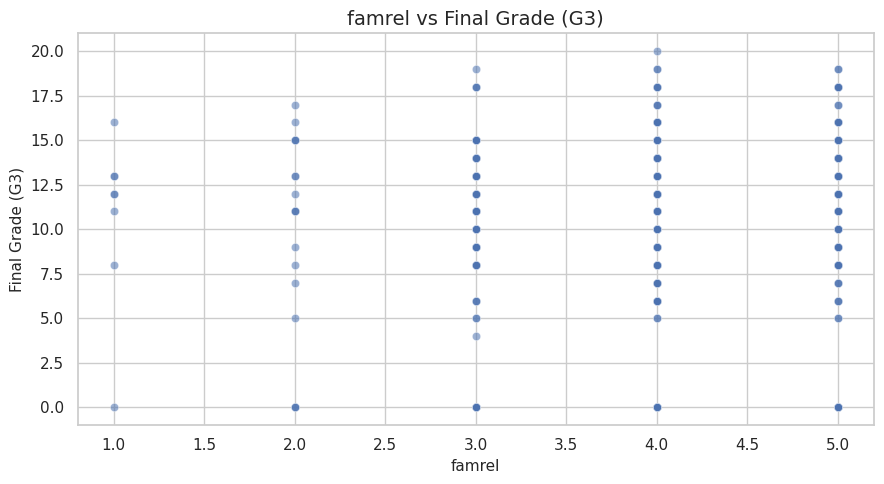

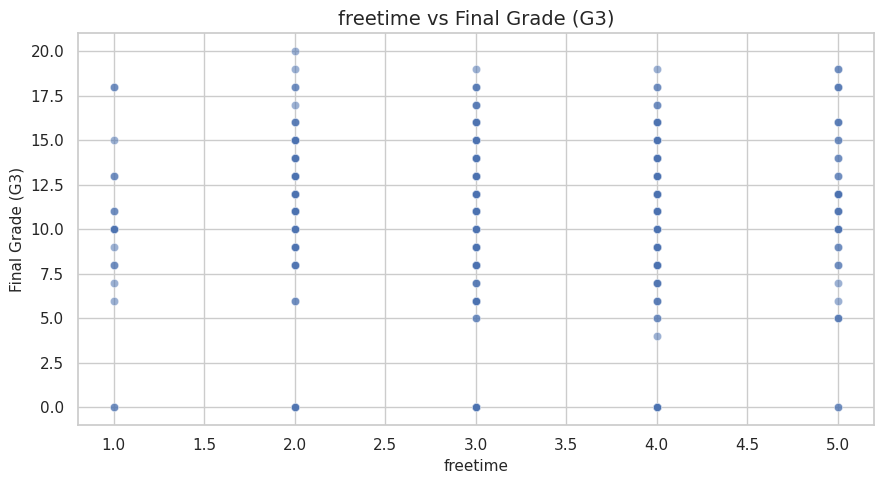

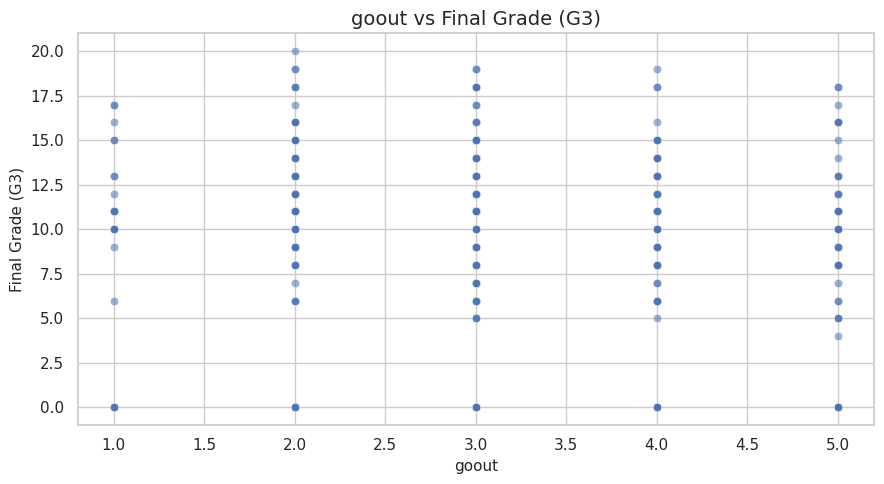

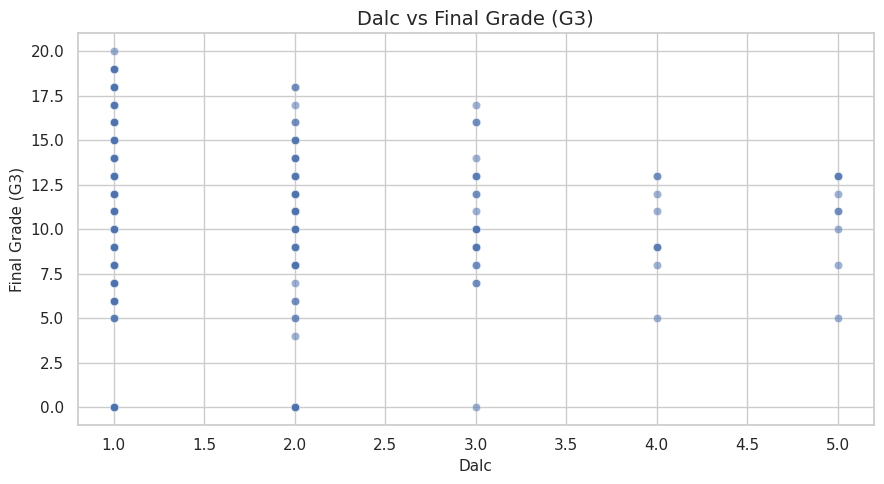

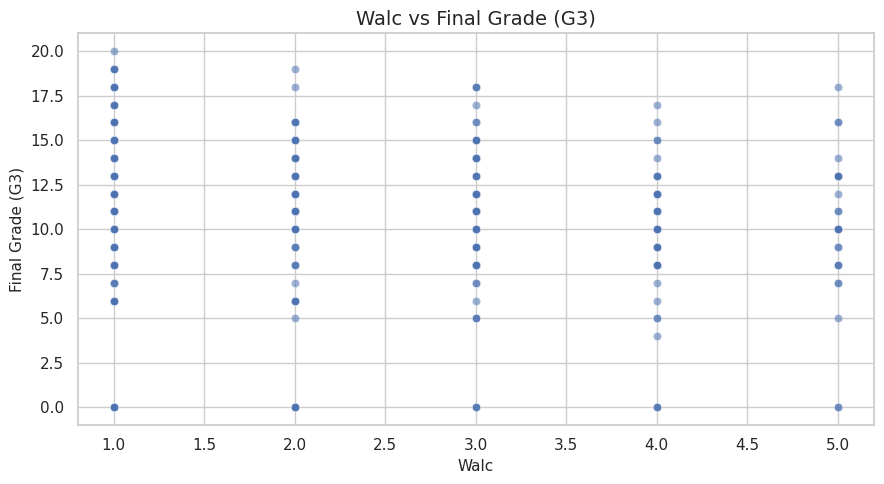

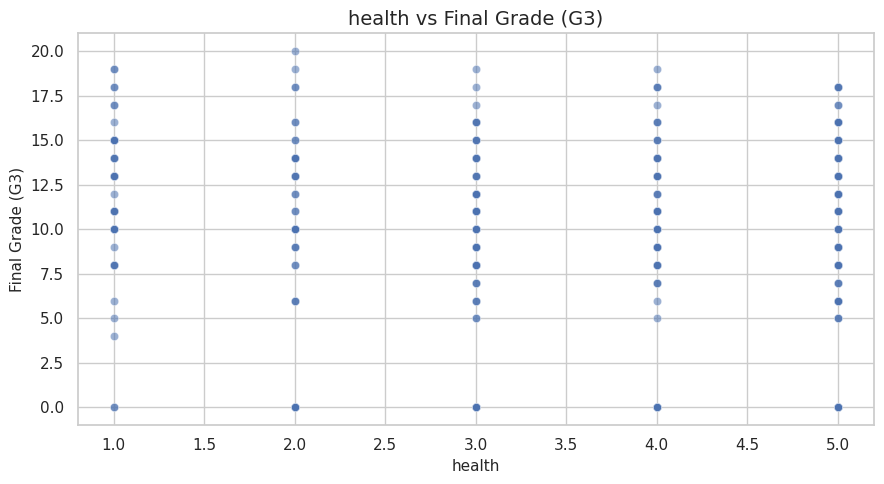

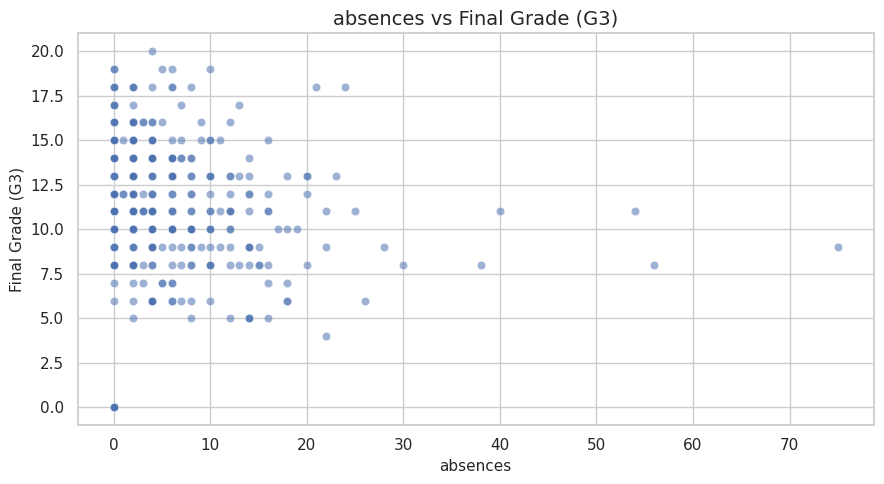

In [31]:
eda_numerical = [
    col for col in numerical_columns
    if col not in ["G1", "G2", "G3"]
]

for column in eda_numerical:

    plt.figure(figsize=(9, 5))

    sns.scatterplot(
        data=df,
        x=column,
        y=TARGET,
        alpha=0.55
    )

    plt.title(f"{column} vs Final Grade (G3)")
    plt.xlabel(column)
    plt.ylabel("Final Grade (G3)")

    plt.tight_layout()
    plt.show()

## **FEATURE ENGINEERING**

In [32]:
model_df = df.copy()

# Average parental education
model_df["parent_education_avg"] = (
    model_df["Medu"] + model_df["Fedu"]
) / 2

# Average alcohol consumption
model_df["alcohol_consumption_avg"] = (
    model_df["Dalc"] + model_df["Walc"]
) / 2

# Social activity indicator
model_df["social_activity"] = (
    model_df["goout"] + model_df["freetime"]
) / 2

print("Engineered variables created:")
print([
    "parent_education_avg",
    "alcohol_consumption_avg",
    "social_activity"
])

Engineered variables created:
['parent_education_avg', 'alcohol_consumption_avg', 'social_activity']


## **ENGINEERED FEATURE ANALYSIS**

In [33]:
engineered_features = [
    "parent_education_avg",
    "alcohol_consumption_avg",
    "social_activity"
]

display(
    model_df[engineered_features + [TARGET]]
    .corr()[TARGET]
    .sort_values(ascending=False)
    .to_frame("Correlation with G3")
)

,Correlation with G3
G3,1.000000
parent_education_avg,0.205224
alcohol_consumption_avg,-0.058245
social_activity,-0.080583


## **PRIMARY EXPERIMENT FEATURES**

In [34]:
TARGET = "G3"

EXCLUDED_PRIMARY = [
    TARGET,
    "G1",
    "G2"
]

X_primary = model_df.drop(
    columns=EXCLUDED_PRIMARY
)

y = model_df[TARGET]

print("Primary experiment:")
print("Target:", TARGET)
print("Excluded variables:", EXCLUDED_PRIMARY)

print("\nNumber of predictor variables:", X_primary.shape[1])

display(
    pd.DataFrame({
        "Predictor": X_primary.columns
    })
)

Primary experiment:
Target: G3
Excluded variables: ['G3', 'G1', 'G2']

Number of predictor variables: 34


,Predictor
0,school
1,sex
2,age
3,address
4,famsize
5,Pstatus
6,Medu
7,Fedu
8,Mjob
9,Fjob


## **PRIMARY FEATURE TYPES**

In [35]:
categorical_features = X_primary.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_primary.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'parent_education_average', 'parent_education_avg', 'alcohol_consumption_avg', 'social_activity']


## **TRAIN / TEST SPLIT**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_primary,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("\nTraining target mean:", round(y_train.mean(), 3))
print("Testing target mean:", round(y_test.mean(), 3))

Training observations: 316
Testing observations: 79

Training target mean: 10.326
Testing target mean: 10.772


## **PREPROCESSING PIPELINE**

In [37]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## **BASELINE MODEL**

In [38]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DummyRegressor(strategy="mean")
        )
    ]
)

baseline_pipeline.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_pipeline.predict(X_test)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline Results")
print("----------------")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Results
----------------
MAE  : 3.6459
RMSE : 4.5502
R²   : -0.0097


## **MACHINE LEARNING MODELS**

In [39]:
models = {

    "Linear Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression())
        ]
    ),

    "Decision Tree Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                DecisionTreeRegressor(
                    random_state=RANDOM_STATE
                )
            )
        ]
    ),

    "Random Forest Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ]
    )
}

print("Three required regression models: Linear Regression, Decision Tree Regression, Random Forest Regression created.")

Three required regression models: Linear Regression, Decision Tree Regression, Random Forest Regression created.


## **INITIAL MODEL TRAINING**

In [40]:
initial_results = []

trained_models = {}

for model_name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    initial_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[model_name] = model

initial_results_df = pd.DataFrame(
    initial_results
).sort_values(
    by="RMSE"
)

display(
    initial_results_df.round(4)
)

,Model,MAE,RMSE,R2
2,Random Forest Regression,3.1508,3.9281,0.2475
0,Linear Regression,3.3953,4.1957,0.1415
1,Decision Tree Regression,3.7595,5.0303,-0.2340


## **CROSS-VALIDATION**

In [41]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X_primary,
        y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,

        "CV MAE Mean":
            -scores["test_MAE"].mean(),

        "CV MAE SD":
            scores["test_MAE"].std(),

        "CV RMSE Mean":
            -scores["test_RMSE"].mean(),

        "CV RMSE SD":
            scores["test_RMSE"].std(),

        "CV R2 Mean":
            scores["test_R2"].mean(),

        "CV R2 SD":
            scores["test_R2"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.round(4)
)

,Model,CV MAE Mean,CV MAE SD,CV RMSE Mean,CV RMSE SD,CV R2 Mean,CV R2 SD
0,Linear Regression,3.4185,0.0501,4.4539,0.1506,0.0256,0.1509
1,Decision Tree Regression,3.9519,0.3943,5.2394,0.3551,-0.3493,0.2334
2,Random Forest Regression,2.9554,0.1889,3.8861,0.2217,0.2677,0.0364


## **FINAL OPTIMISED MODELS**

In [42]:
final_models = {

    "Linear Regression":
        models["Linear Regression"],

    "Decision Tree Regression":
        models["Decision Tree Regression"],

    "Random Forest Regression":
        models["Random Forest Regression"]
}

print("Final selected model set prepared.")

Final selected model set prepared.


## **Final Test Evaluation**

In [43]:
final_results = []
final_predictions = {}

for model_name, model in final_models.items():

    # Linear Regression was already trained,
    # while tuned models are already fitted.
    if model_name == "Linear Regression":
        model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    final_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    final_predictions[model_name] = predictions

final_results_df = pd.DataFrame(
    final_results
).sort_values(
    by="RMSE"
).reset_index(drop=True)

display(
    final_results_df.round(4)
)

,Model,MAE,RMSE,R2
0,Random Forest Regression,3.1508,3.9281,0.2475
1,Linear Regression,3.3953,4.1957,0.1415
2,Decision Tree Regression,3.7595,5.0303,-0.2340


### *MODEL PERFORMANCE COMPARISON*

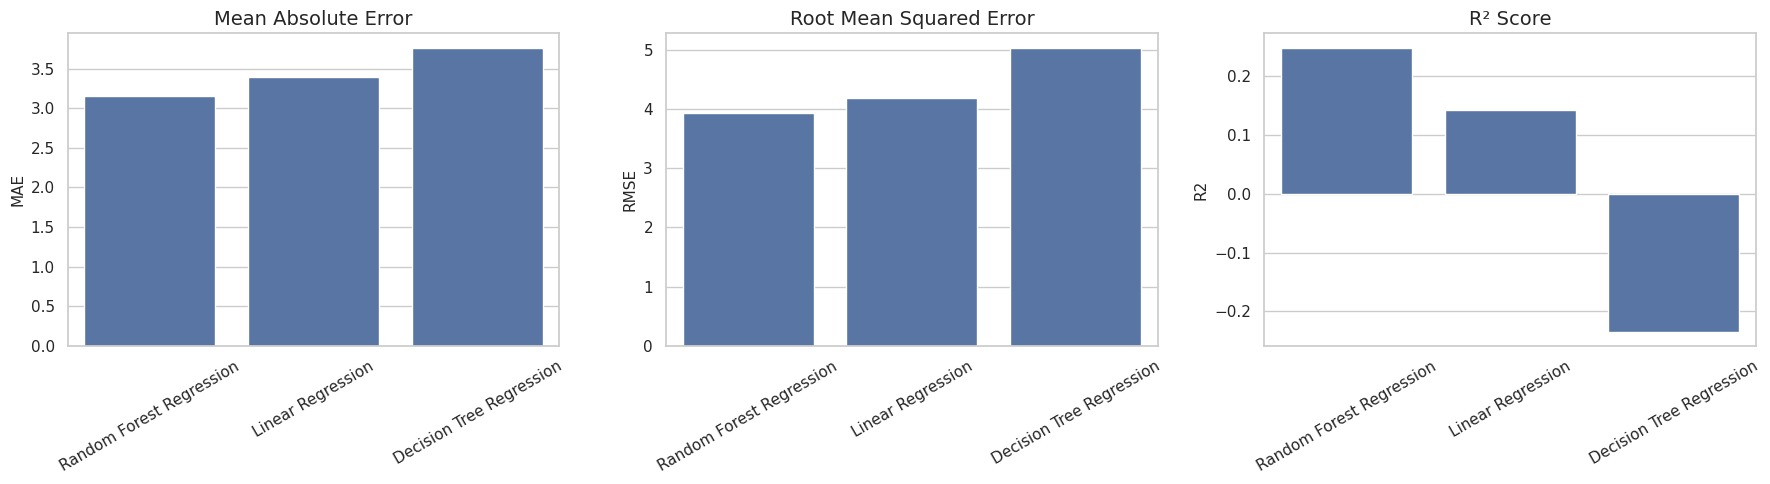

In [44]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

sns.barplot(
    data=final_results_df,
    x="Model",
    y="MAE",
    ax=axes[0]
)

axes[0].set_title("Mean Absolute Error")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=final_results_df,
    x="Model",
    y="RMSE",
    ax=axes[1]
)

axes[1].set_title("Root Mean Squared Error")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(
    data=final_results_df,
    x="Model",
    y="R2",
    ax=axes[2]
)

axes[2].set_title("R² Score")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### *ACTUAL VS PREDICTED GRADES*

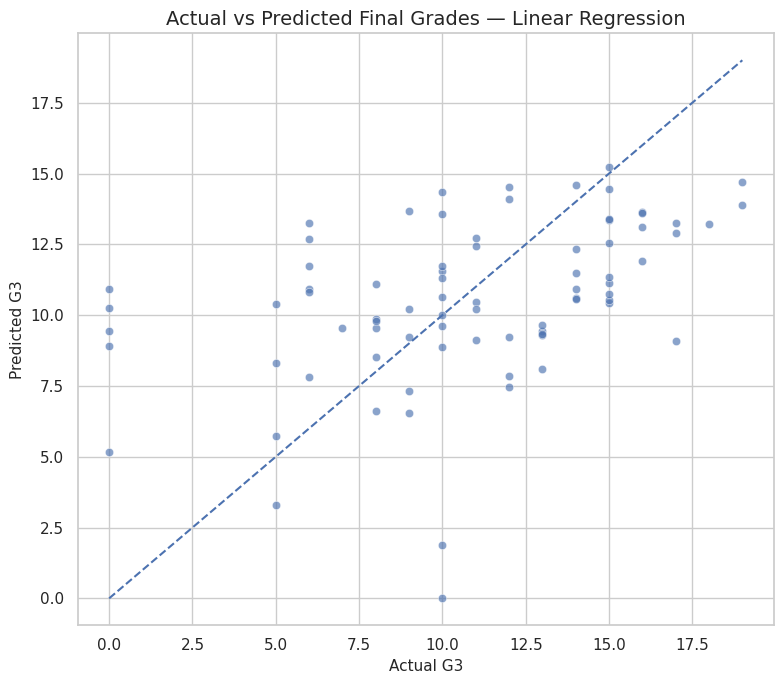

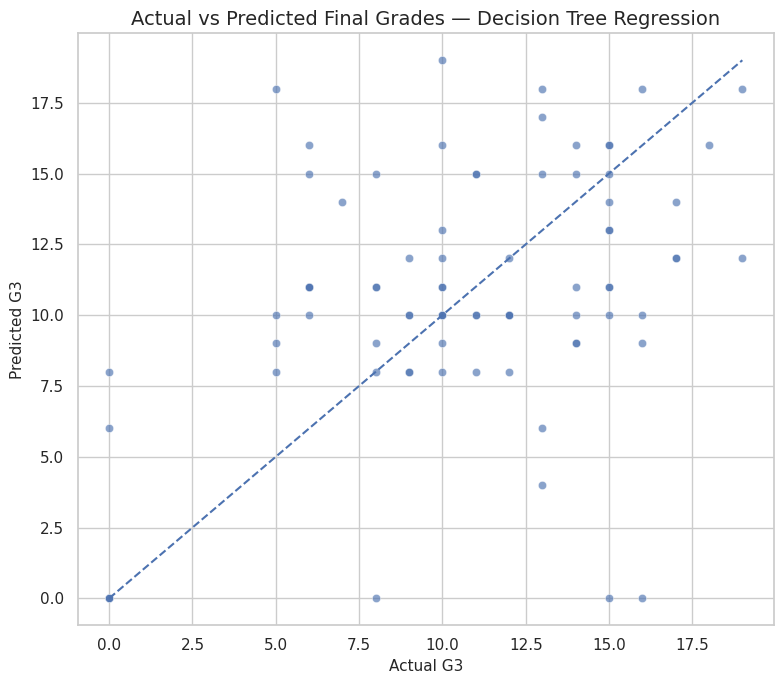

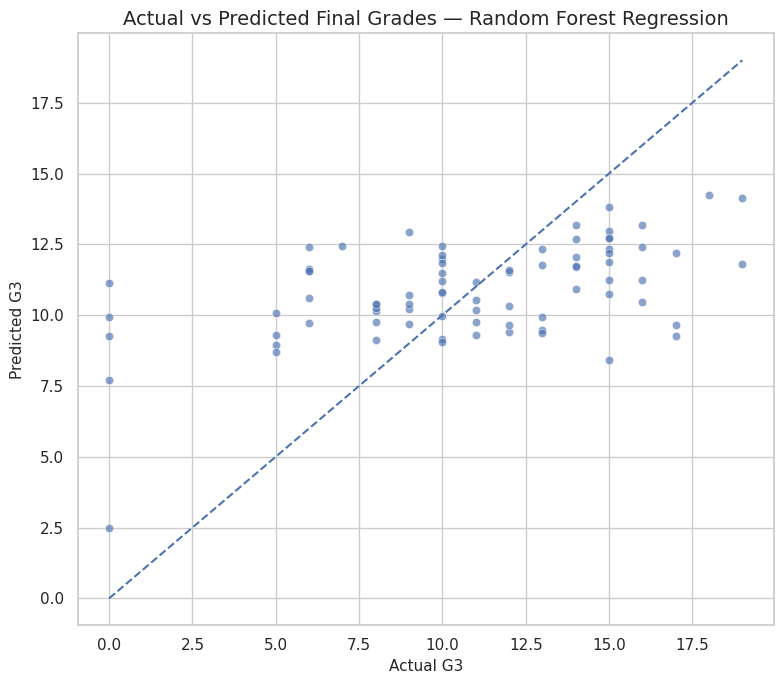

In [45]:
for model_name, predictions in final_predictions.items():

    plt.figure(figsize=(8, 7))

    sns.scatterplot(
        x=y_test,
        y=predictions,
        alpha=0.65
    )

    min_value = min(
        y_test.min(),
        predictions.min()
    )

    max_value = max(
        y_test.max(),
        predictions.max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.title(
        f"Actual vs Predicted Final Grades — {model_name}"
    )

    plt.xlabel("Actual G3")
    plt.ylabel("Predicted G3")

    plt.tight_layout()
    plt.show()

### *RESIDUAL ANALYSIS*

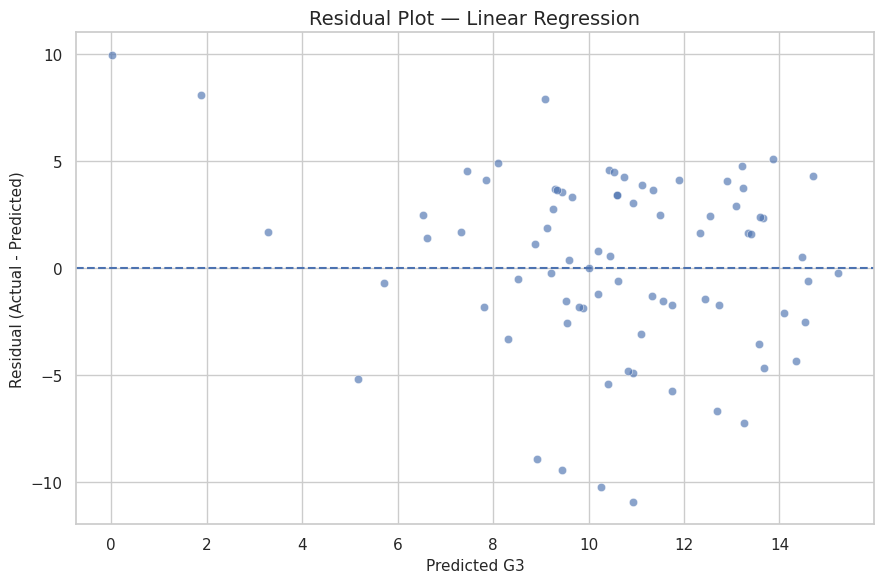

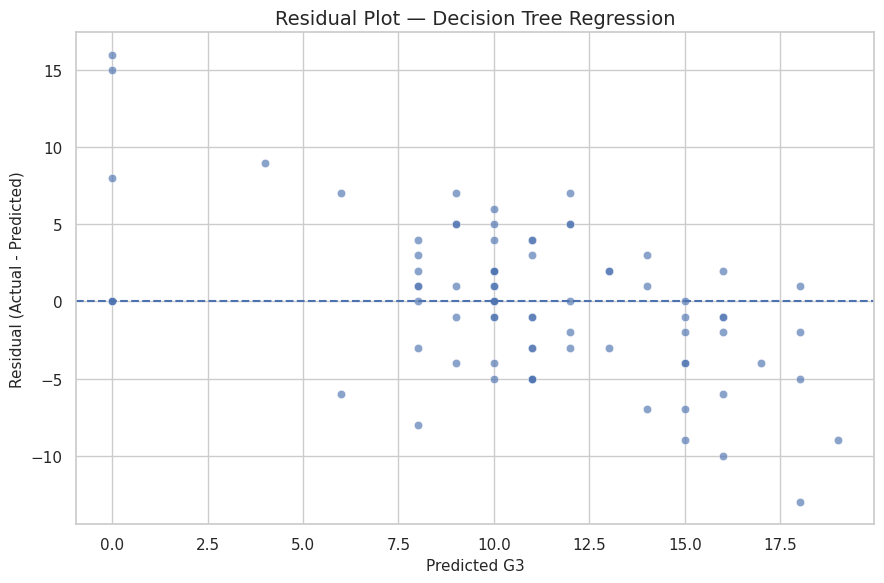

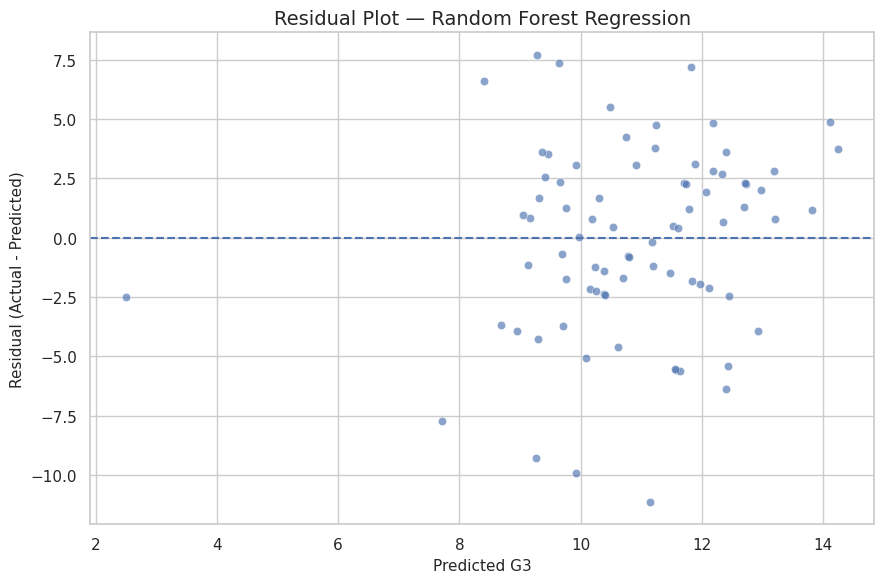

In [46]:
residual_results = {}

for model_name, predictions in final_predictions.items():

    residuals = y_test.values - predictions

    residual_results[model_name] = residuals

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        x=predictions,
        y=residuals,
        alpha=0.65
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.title(
        f"Residual Plot — {model_name}"
    )

    plt.xlabel("Predicted G3")
    plt.ylabel("Residual (Actual - Predicted)")

    plt.tight_layout()
    plt.show()

### *RESIDUAL DISTRIBUTIONS*

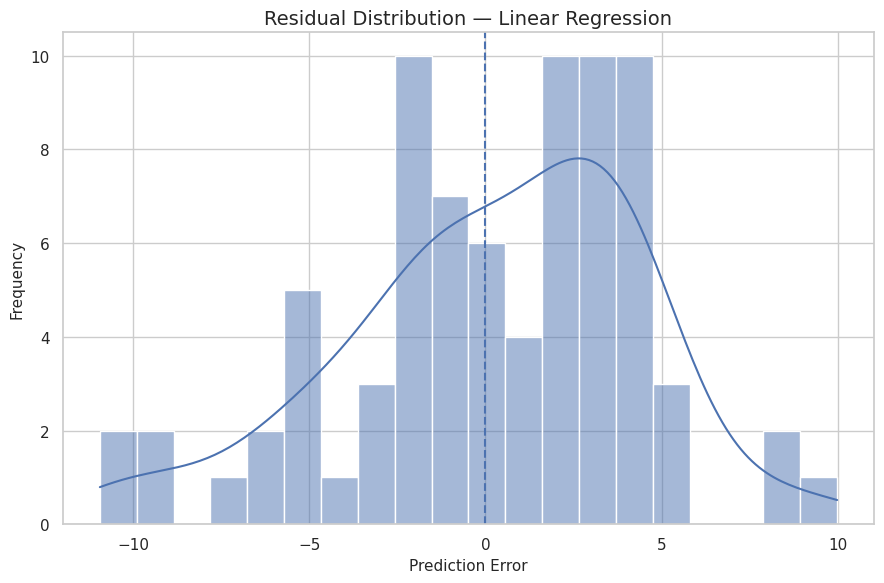

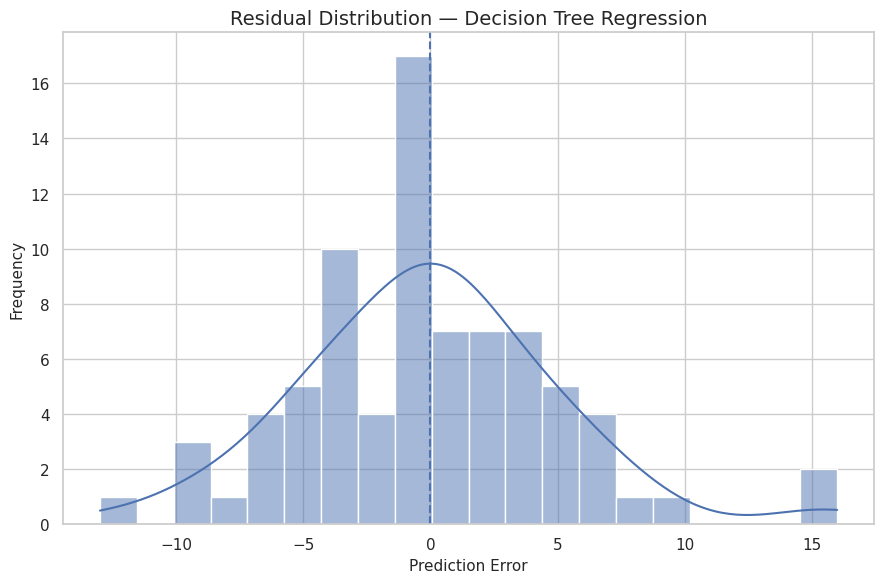

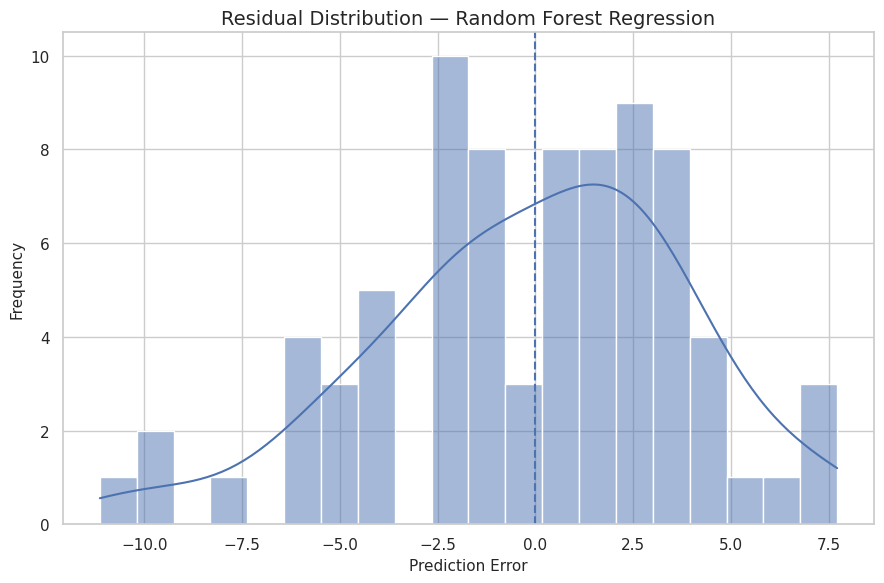

In [47]:
for model_name, residuals in residual_results.items():

    plt.figure(figsize=(9, 6))

    sns.histplot(
        residuals,
        kde=True,
        bins=20
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.title(
        f"Residual Distribution — {model_name}"
    )

    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## **ERROR ANALYSIS**

In [48]:
error_summary = []

for model_name, predictions in final_predictions.items():

    errors = y_test.values - predictions

    error_summary.append({
        "Model": model_name,
        "Mean Error": np.mean(errors),
        "Median Error": np.median(errors),
        "Std Error": np.std(errors),
        "Minimum Error": np.min(errors),
        "Maximum Error": np.max(errors),
        "Mean Absolute Error": np.mean(np.abs(errors))
    })

error_summary_df = pd.DataFrame(error_summary)

display(
    error_summary_df.round(4)
)

,Model,Mean Error,Median Error,Std Error,Minimum Error,Maximum Error,Mean Absolute Error
0,Linear Regression,0.2383,0.7929,4.1889,-10.9401,9.9842,3.3953
1,Decision Tree Regression,-0.0633,0.0000,5.0299,-13.0000,16.0000,3.7595
2,Random Forest Regression,-0.0961,0.4800,3.9269,-11.1400,7.7200,3.1508


## **BEST MODEL**

In [49]:
best_model_name = final_results_df.iloc[0]["Model"]

best_model = final_models[best_model_name]

print("Best-performing model based on RMSE:")
print(best_model_name)

print("\nPerformance:")
display(
    final_results_df[
        final_results_df["Model"] == best_model_name
    ].round(4)
)

Best-performing model based on RMSE:
Random Forest Regression

Performance:


,Model,MAE,RMSE,R2
0,Random Forest Regression,3.1508,3.9281,0.2475


## **RANDOM FOREST FEATURE IMPORTANCE**

In [50]:
rf_final = models["Random Forest Regression"]


rf_preprocessor = rf_final.named_steps["preprocessor"]
rf_model = rf_final.named_steps["model"]


feature_names = rf_preprocessor.get_feature_names_out()

importance_values = rf_model.feature_importances_


feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})


feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance_df.head(20).round(4)
)

,Feature,Importance
0,num__absences,0.1876
1,num__failures,0.1396
2,num__health,0.0499
3,num__age,0.0439
4,num__social_activity,0.0356
5,num__goout,0.0327
6,num__studytime,0.0320
7,num__traveltime,0.0306
8,num__freetime,0.0261
9,num__alcohol_consumption_avg,0.0237


### *RANDOM FOREST FEATURE IMPORTANCE VISUALISATION*

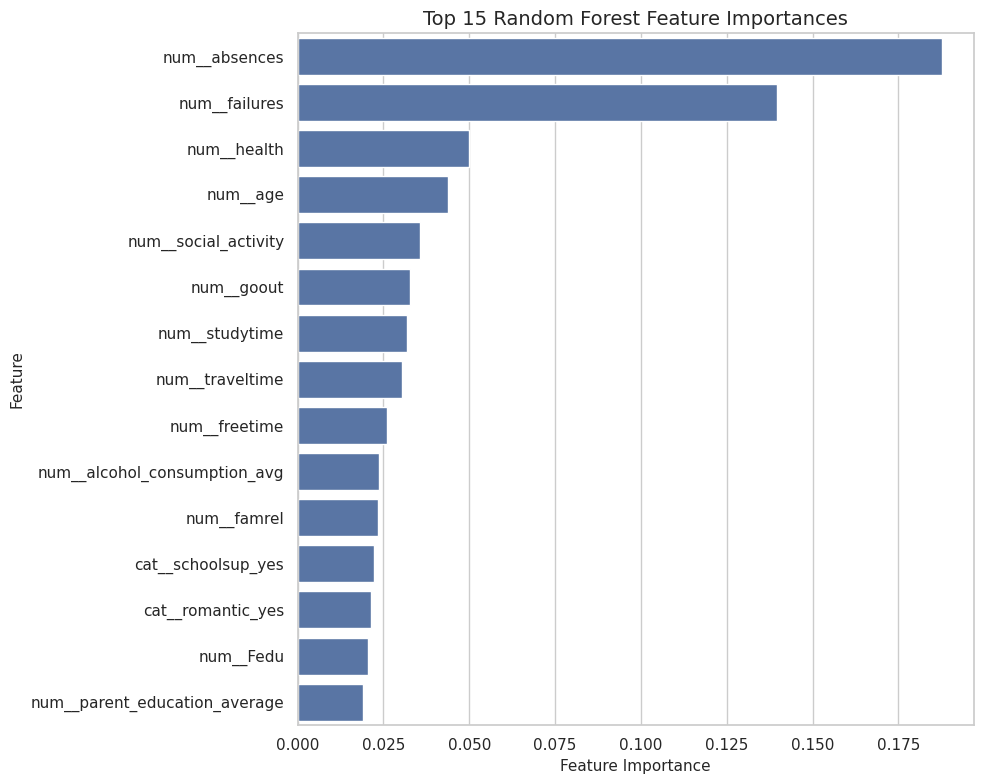

In [51]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## **PERMUTATION IMPORTANCE**

In [52]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation.importances_mean,
    "Importance SD": permutation.importances_std
})

permutation_df = (
    permutation_df
    .sort_values(
        by="Importance Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    permutation_df.head(20).round(4)
)

,Feature,Importance Mean,Importance SD
0,failures,0.5967,0.1512
1,absences,0.3846,0.1601
2,sex,0.1446,0.0544
3,goout,0.1018,0.0549
4,schoolsup,0.0866,0.0335
5,age,0.0574,0.0478
6,guardian,0.0559,0.0314
7,Medu,0.0498,0.0218
8,parent_education_avg,0.0474,0.0212
9,famsup,0.0290,0.0225


### *PERMUTATION IMPORTANCE VISUALISATION*

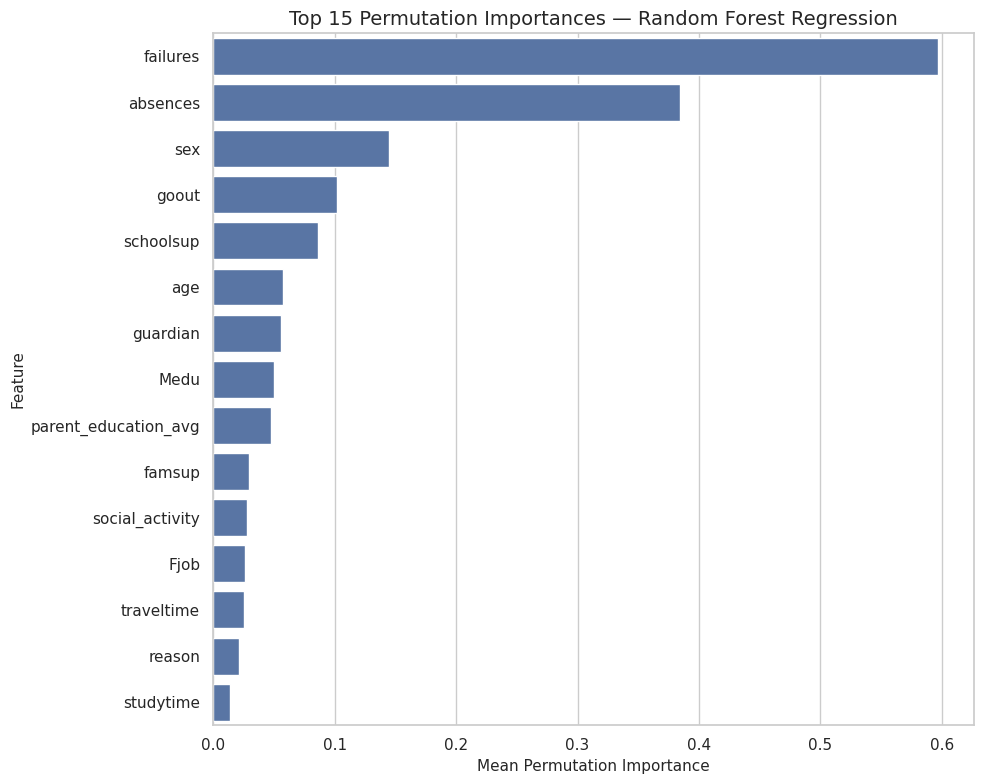

In [53]:
top_permutation = permutation_df.head(15)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_permutation,
    x="Importance Mean",
    y="Feature"
)

plt.title(
    f"Top 15 Permutation Importances — {best_model_name}"
)

plt.xlabel("Mean Permutation Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## **COMPLETE PERFORMANCE SUMMARY**

In [54]:
performance_summary = final_results_df.copy()

performance_summary["MAE"] = performance_summary["MAE"].round(4)
performance_summary["RMSE"] = performance_summary["RMSE"].round(4)
performance_summary["R2"] = performance_summary["R2"].round(4)

display(performance_summary)

,Model,MAE,RMSE,R2
0,Random Forest Regression,3.1508,3.9281,0.2475
1,Linear Regression,3.3953,4.1957,0.1415
2,Decision Tree Regression,3.7595,5.0303,-0.2340


## **SECONDARY G1/G2 BENCHMARK**

In [55]:
X_with_grades = model_df.drop(
    columns=[TARGET]
)

y_benchmark = model_df[TARGET]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_with_grades,
    y_benchmark,
    test_size=0.20,
    random_state=RANDOM_STATE
)

categorical_benchmark = X_with_grades.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_benchmark = X_with_grades.select_dtypes(
    include=[np.number]
).columns.tolist()

benchmark_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_benchmark
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        drop="first"
                    )
                )
            ]),
            categorical_benchmark
        )
    ]
)

## **G1/G2 BENCHMARK MODELS**

In [1]:

        Pipeline([
            ("preprocessor", benchmark_preprocessor),
            ("model", LinearRegression())
        ]),

    "Decision Tree Regression":
        Pipeline([
            ("preprocessor", benchmark_preprocessor),
            (
                "model",
                DecisionTreeRegressor(
                    random_state=RANDOM_STATE
                )
            )
        ]),

    "Random Forest Regression":
        Pipeline([
            ("preprocessor", benchmark_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        ])
}

benchmark_results = []

for model_name, model in benchmark_models.items():

    model.fit(
        X_train_b,
        y_train_b
    )

    predictions = model.predict(
        X_test_b
    )

    benchmark_results.append({
        "Model": model_name,

        "MAE": mean_absolute_error(
            y_test_b,
            predictions
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_test_b,
                predictions
            )
        ),

        "R2": r2_score(
            y_test_b,
            predictions
        )
    })

benchmark_results_df = pd.DataFrame(
    benchmark_results
).sort_values(
    by="RMSE"
)

display(
    benchmark_results_df.round(4)
)

IndentationError: unindent does not match any outer indentation level (<string>, line 6)

## **EARLY PREDICTION VS G1/G2 BENCHMARK**

In [57]:
primary_comparison = final_results_df.copy()
primary_comparison["Experiment"] = "Early Prediction (without G1/G2)"

benchmark_comparison = benchmark_results_df.copy()
benchmark_comparison["Experiment"] = "Grade-Informed Prediction (with G1/G2)"

comparison_df = pd.concat(
    [
        primary_comparison,
        benchmark_comparison
    ],
    ignore_index=True
)

display(
    comparison_df[
        [
            "Experiment",
            "Model",
            "MAE",
            "RMSE",
            "R2"
        ]
    ].round(4)
)

,Experiment,Model,MAE,RMSE,R2
0,Early Prediction (without G1/G2),Random Forest Regression,3.1508,3.9281,0.2475
1,Early Prediction (without G1/G2),Linear Regression,3.3953,4.1957,0.1415
2,Early Prediction (without G1/G2),Decision Tree Regression,3.7595,5.0303,-0.2340
3,Grade-Informed Prediction (with G1/G2),Random Forest Regression,1.1827,1.9840,0.8080
4,Grade-Informed Prediction (with G1/G2),Decision Tree Regression,1.3038,2.3734,0.7253
5,Grade-Informed Prediction (with G1/G2),Linear Regression,1.6467,2.3784,0.7241


## **BENCHMARK IMPROVEMENT**

In [58]:
early = (
    final_results_df
    .set_index("Model")
)

with_grades = (
    benchmark_results_df
    .set_index("Model")
)

benchmark_improvement = pd.DataFrame({
    "MAE Improvement":
        early["MAE"] - with_grades["MAE"],

    "RMSE Improvement":
        early["RMSE"] - with_grades["RMSE"],

    "R2 Improvement":
        with_grades["R2"] - early["R2"]
})

display(
    benchmark_improvement.round(4)
)

,MAE Improvement,RMSE Improvement,R2 Improvement
Model,,,
Decision Tree Regression,2.4557,2.6569,0.9593
Linear Regression,1.7486,1.8173,0.5826
Random Forest Regression,1.9680,1.9440,0.5605
